In [ ]:
"""
This script used to calculate the price of a barrier option using the Black-Scholes model.
Solved with Finite Difference Method (FDM) on Partial Differential Equation (PDE).
"""
import QuantLib as ql
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np


# 定义市场参数
start_date = "2024-11-11"
end_date = "2025-11-11"
risk_free_rate = 0.05
barrier_payoff = 0.07
barrier_ratio = 1.4
instrument = "NVDA"

# 下载数据
nvda_data = yf.download(instrument, start=start_date, end=end_date, auto_adjust=True, proxy="http://127.0.0.1:1087")

# 计算基于收盘价的历史波动率
close_prices = nvda_data[('Close', instrument)].values
log_returns = np.diff(np.log(close_prices))
volatility = np.std(log_returns) * np.sqrt(252)

spot_price = nvda_data.iloc[0][('Close', instrument)]
strike_price = spot_price
barrier = strike_price * barrier_ratio
end_date = nvda_data.iloc[-1].name
print(end_date)
print(f"Strike Price: {strike_price}, Barrier: {barrier}")
print(f"Calculated Annualized Volatility: {volatility*100:.2f}%")

exercise_date = ql.Date(end_date.day, end_date.month, end_date.year)

/var/folders/x4/f_7h47xj68q_sncgrpbwqq600000gn/T/ipykernel_3141/1236257972.py:19: DeprecationWarning: Set proxy via new config function: yf.set_config(proxy=proxy)
  nvda_data = yf.download(instrument, start=start_date, end=end_date, auto_adjust=True, proxy="http://127.0.0.1:1087")
[*********************100%***********************]  1 of 1 completed

2025-11-10 00:00:00
Strike Price: 145.21835327148438, Barrier: 210.56661224365234
Calculated Annualized Volatility: 50.01%


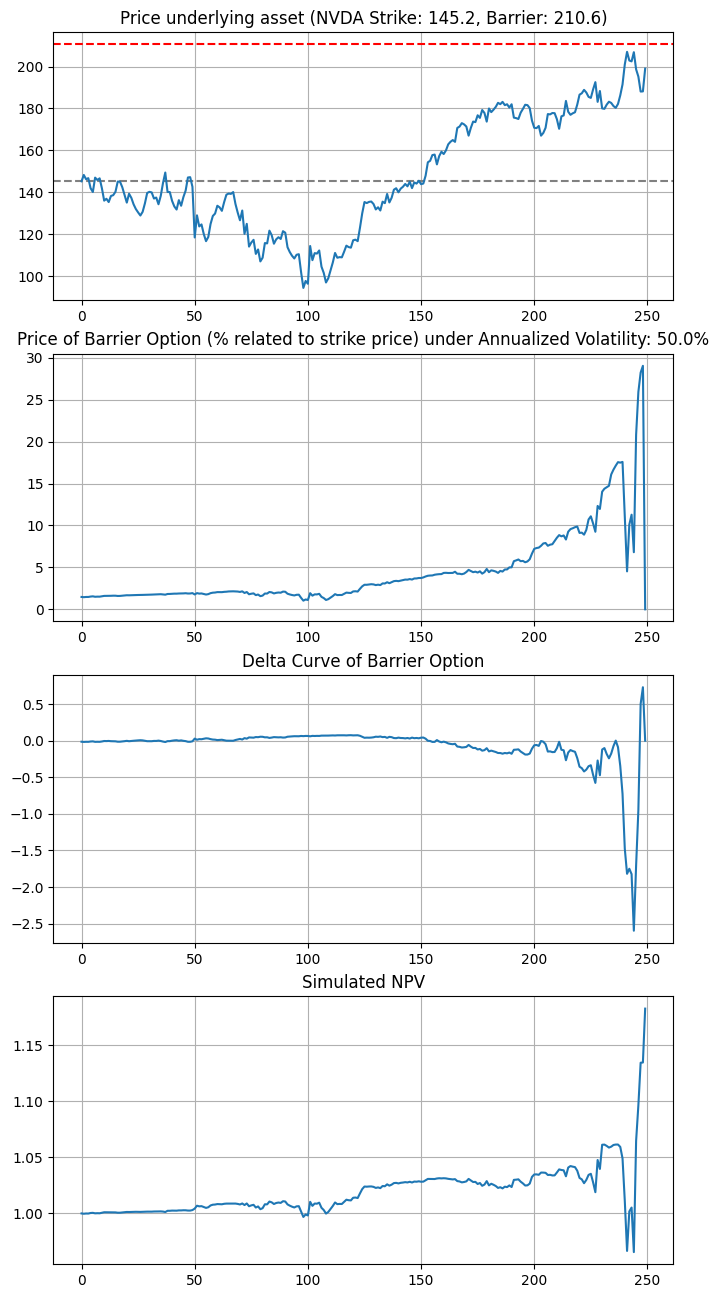

In [15]:

# 定义 QuantLib 对象
spot = ql.SimpleQuote(spot_price)
q_rate = ql.YieldTermStructureHandle(ql.FlatForward(0, ql.NullCalendar(), 0.0, ql.Actual365Fixed()))
r_rate = ql.YieldTermStructureHandle(ql.FlatForward(0, ql.NullCalendar(), risk_free_rate, ql.Actual365Fixed()))
vol = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(0, ql.NullCalendar(), volatility, ql.Actual365Fixed()))

# Black-Scholes 模型
process = ql.BlackScholesMertonProcess(ql.QuoteHandle(spot), q_rate, r_rate, vol)

# 构造障碍期权
payoff = ql.PlainVanillaPayoff(ql.Option.Call, strike_price)
exercise = ql.EuropeanExercise(exercise_date)
option = ql.BarrierOption(ql.Barrier.UpOut, barrier, barrier_payoff, payoff, exercise)

# 设置有限差分引擎
engine = ql.FdBlackScholesBarrierEngine(process, 100, 200, 0)
option.setPricingEngine(engine)

prices = []
npvs = []
deltas = []
last_price = strike_price
last_delta = 0
simulated_npv = 1.0
simulated_npvs = []
for idx, data in nvda_data.iterrows():
    ql.Settings.instance().evaluationDate = ql.Date(data.name.day, data.name.month, data.name.year)
    price = data[('Close', instrument)]
    spot.setValue(price)
    prices.append(price)
    npv = option.NPV()
    npvs.append(npv / strike_price * 100)
    delta = option.delta()
    deltas.append(delta)

    pnl = (price / last_price - 1) * last_delta 
    simulated_npv *= (1 + pnl)
    simulated_npvs.append(simulated_npv)
    last_price = price
    last_delta = delta

plt.figure(figsize=(8, 16))
plt.subplot(4, 1, 1)
plt.grid()
plt.title(f"Price underlying asset ({instrument} Strike: {strike_price:.1f}, Barrier: {barrier:.1f})")
plt.axhline(y=barrier, color='r', linestyle='--', label='Barrier')
plt.axhline(y=strike_price, color='grey', linestyle='--', label='Strike')
plt.plot(prices, label="Price")
plt.subplot(4, 1, 2)
plt.grid()
plt.title(f"Price of Barrier Option (% related to strike price) under Annualized Volatility: {volatility*100:.1f}%")
plt.plot(npvs, label="NPV")
plt.subplot(4, 1, 3)
plt.grid()
plt.title("Delta Curve of Barrier Option")
plt.plot(deltas, label="Delta")
plt.subplot(4, 1, 4)
plt.grid()
plt.title("Simulated NPV")
plt.plot(simulated_npvs, label="Simulated NPV")
plt.show()
